# F1 Strategy Lab: Exploratory Data Analysis
Analyzing F1 race strategy optimization using 2020 Abu Dhabi race data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/2020_abudhabi_race.csv")
print(df.shape)

(1044, 31)


In [2]:
# Display column names
print('Columns in dataset:')
print(df.columns.tolist())

Columns in dataset:
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [3]:
# Display first few rows
df.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,2121.490,GAS,10,112.727,1.0,1.0,NaN,NaN,NaN,46.099,...,False,AlphaTauri,2008.601,2020-12-13 13:13:28.798,1,10.0,False,NaN,False,False
1,2226.318,GAS,10,104.828,2.0,1.0,NaN,NaN,18.497,43.988,...,False,AlphaTauri,2121.490,2020-12-13 13:15:21.687,1,9.0,False,NaN,False,True
2,2330.935,GAS,10,104.617,3.0,1.0,NaN,NaN,18.237,43.856,...,False,AlphaTauri,2226.318,2020-12-13 13:17:06.515,1,9.0,False,NaN,False,True
3,2435.221,GAS,10,104.286,4.0,1.0,NaN,NaN,18.214,43.867,...,False,AlphaTauri,2330.935,2020-12-13 13:18:51.132,1,9.0,False,NaN,False,True
4,2539.741,GAS,10,104.520,5.0,1.0,NaN,NaN,18.181,44.103,...,False,AlphaTauri,2435.221,2020-12-13 13:20:35.418,1,9.0,False,NaN,False,True


In [4]:
# Select relevant columns
relevant_cols = ['Driver', 'LapNumber', 'LapTime', 'Compound', 'TyreLife', 'PitOutTime', 'PitInTime', 'Stint', 'IsAccurate', 'Deleted', 'TrackStatus']
df = df[relevant_cols].copy()
print(f'Selected {len(relevant_cols)} relevant columns')
df.head()

Selected 11 relevant columns


,Driver,LapNumber,LapTime,Compound,TyreLife,PitOutTime,PitInTime,Stint,IsAccurate,Deleted,TrackStatus
0,GAS,1.0,112.727,SOFT,4.0,NaN,NaN,1.0,False,False,1
1,GAS,2.0,104.828,SOFT,5.0,NaN,NaN,1.0,True,False,1
2,GAS,3.0,104.617,SOFT,6.0,NaN,NaN,1.0,True,False,1
3,GAS,4.0,104.286,SOFT,7.0,NaN,NaN,1.0,True,False,1
4,GAS,5.0,104.520,SOFT,8.0,NaN,NaN,1.0,True,False,1


In [5]:
# Count unique drivers
print(f'Number of drivers: {df["Driver"].nunique()}')
print('\nDriver counts:')
print(df['Driver'].value_counts().head(10))

Number of drivers: 20

Driver counts:
Driver
GAS    55
STR    55
RIC    55
ALB    55
NOR    55
HAM    55
VER    55
OCO    55
BOT    55
SAI    55
Name: count, dtype: int64


In [6]:
# Count tire compounds
print('Tire compound distribution:')
print(df['Compound'].value_counts())

Tire compound distribution:
Compound
HARD      758
MEDIUM    231
SOFT       55
Name: count, dtype: int64


In [7]:
# Stint analysis
print('Stint distribution:')
print(df['Stint'].value_counts().sort_index())

Stint distribution:
Stint
1.0    304
2.0    695
3.0     40
4.0      5
Name: count, dtype: int64


In [8]:
df = df.sort_values(["Driver", "LapNumber"]).reset_index(drop=True)

df["PrevStint"] = df.groupby("Driver")["Stint"].shift(1)
df["PitStop"] = (df["Stint"] != df["PrevStint"]).astype(int)

# first lap for each driver is not a pit stop
df.loc[df.groupby("Driver").cumcount() == 0, "PitStop"] = 0

print('Pit stop detection complete')
print(df[df['PitStop']==1][['Driver', 'LapNumber', 'Stint', 'PitStop']].head(10))

Pit stop detection complete
    Driver  LapNumber  Stint  PitStop
10     ALB       11.0    2.0        1
65     BOT       11.0    2.0        1
120    FIT       11.0    2.0        1
144    FIT       35.0    3.0        1
158    FIT       49.0    4.0        1
173    GAS       11.0    2.0        1
245    GIO       28.0    2.0        1
282    HAM       11.0    2.0        1
337    KVY       11.0    2.0        1
392    LAT       12.0    2.0        1


In [9]:
# Count pit stops per driver
pit_counts = df[df['PitStop']==1].groupby('Driver').size()
print('Pit stops per driver:')
print(pit_counts.value_counts().sort_index())

Pit stops per driver:
1    16
2     2
3     1
Name: count, dtype: int64


In [10]:
# Analyze pit lap characteristics
pit_laps = df[df['PitStop']==1][['Driver', 'LapNumber', 'LapTime', 'Stint', 'Compound']]
print(f'Number of pit laps detected: {len(pit_laps)}')
print('\nPit lap times:')
print(pit_laps['LapTime'].describe())

Number of pit laps detected: 23

Pit lap times:
count      9.000000
mean     124.378222
std        3.064420
min      122.555000
25%      123.079000
50%      123.180000
75%      123.659000
max      132.398000
Name: LapTime, dtype: float64


In [11]:
# Clean data: remove NaN lap times and extreme outliers
clean_df = df.dropna(subset=['LapTime']).copy()
# Convert LapTime to seconds  
clean_df['LapTime'] = pd.to_numeric(clean_df['LapTime'], errors="coerce")
# Remove outliers (lap times > 150 seconds indicate safety car laps or issues)
clean_df = clean_df[clean_df['LapTime'] <= 150]
print(f'Clean data: {clean_df.shape[0]} laps (removed {df.shape[0] - clean_df.shape[0]} rows)')

Clean data: 1020 laps (removed 24 rows)


In [12]:
# Analyze raw degradation across all laps
degradation_df = clean_df.groupby(['Compound', 'TyreLife'])['LapTime'].agg(['mean', 'count']).reset_index()
degradation_df.columns = ['Compound', 'TyreLife', 'LapTime', 'Count']
print('Raw degradation data (first 20 rows):')
print(degradation_df.head(20))

Raw degradation data (first 20 rows):
   Compound  TyreLife     LapTime  Count
0      HARD       1.0  118.209667      6
1      HARD       2.0  128.346059     17
2      HARD       3.0  121.783333     15
3      HARD       4.0  105.030200     20
4      HARD       5.0  104.318950     20
5      HARD       6.0  103.903900     20
6      HARD       7.0  104.003450     20
7      HARD       8.0  104.137050     20
8      HARD       9.0  104.118316     19
9      HARD      10.0  109.437526     19
10     HARD      11.0  109.936368     19
11     HARD      12.0  109.869158     19
12     HARD      13.0  107.729278     18
13     HARD      14.0  103.639789     19
14     HARD      15.0  103.515947     19
15     HARD      16.0  103.587526     19
16     HARD      17.0  103.686263     19
17     HARD      18.0  103.808000     19
18     HARD      19.0  103.549211     19
19     HARD      20.0  103.316579     19


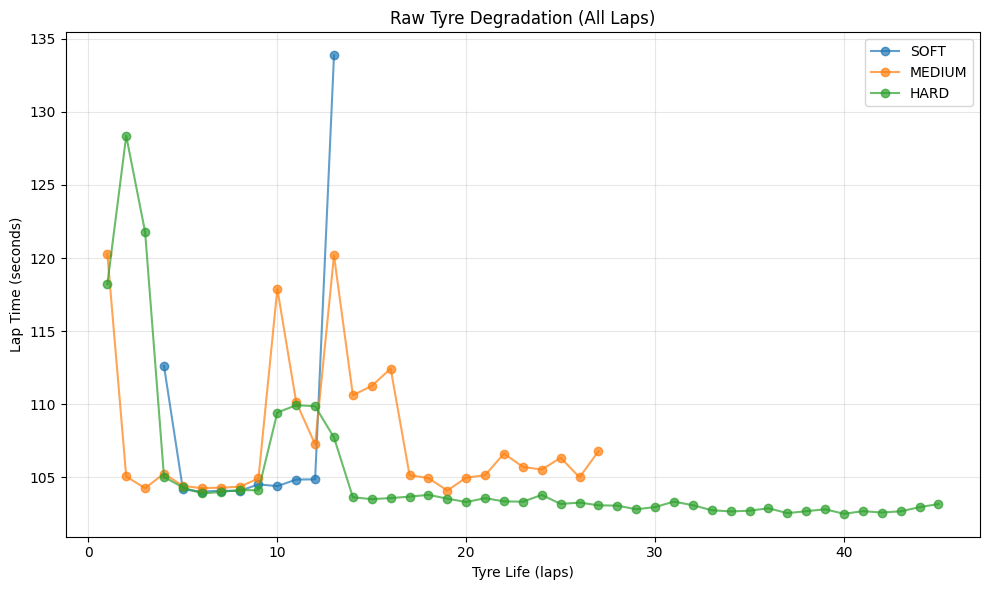

In [13]:
# Plot raw degradation
fig, ax = plt.subplots(figsize=(10, 6))
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    data = degradation_df[degradation_df['Compound'] == compound]
    ax.plot(data['TyreLife'], data['LapTime'], marker='o', label=compound, alpha=0.7)
ax.set_xlabel('Tyre Life (laps)')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Raw Tyre Degradation (All Laps)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Filter data: remove pit laps and early laps in stint (unstable signal)
filtered_df = clean_df[(clean_df['PitStop'] != 1) & (clean_df['TyreLife'] > 2)].copy()
print(f'Filtered data: {filtered_df.shape[0]} laps (removed {clean_df.shape[0] - filtered_df.shape[0]} rows)')
print(f'Removed pit laps: {(clean_df["PitStop"] == 1).sum()}')
print(f'Removed early laps: {(clean_df["TyreLife"] <= 2).sum()}')

Filtered data: 972 laps (removed 48 rows)
Removed pit laps: 9
Removed early laps: 47


In [15]:
# Aggregate filtered degradation
filtered_deg_df = filtered_df.groupby(['Compound', 'TyreLife'])['LapTime'].agg(['mean', 'count']).reset_index()
filtered_deg_df.columns = ['Compound', 'TyreLife', 'LapTime', 'Count']
print('Filtered degradation data (first 20 rows):')
print(filtered_deg_df.head(20))

Filtered degradation data (first 20 rows):
   Compound  TyreLife     LapTime  Count
0      HARD       3.0  121.783333     15
1      HARD       4.0  105.030200     20
2      HARD       5.0  104.318950     20
3      HARD       6.0  103.903900     20
4      HARD       7.0  104.003450     20
5      HARD       8.0  104.137050     20
6      HARD       9.0  104.118316     19
7      HARD      10.0  109.437526     19
8      HARD      11.0  109.936368     19
9      HARD      12.0  109.869158     19
10     HARD      13.0  107.729278     18
11     HARD      14.0  103.639789     19
12     HARD      15.0  103.515947     19
13     HARD      16.0  103.587526     19
14     HARD      17.0  103.686263     19
15     HARD      18.0  103.808000     19
16     HARD      19.0  103.549211     19
17     HARD      20.0  103.316579     19
18     HARD      21.0  103.580474     19
19     HARD      22.0  103.361316     19


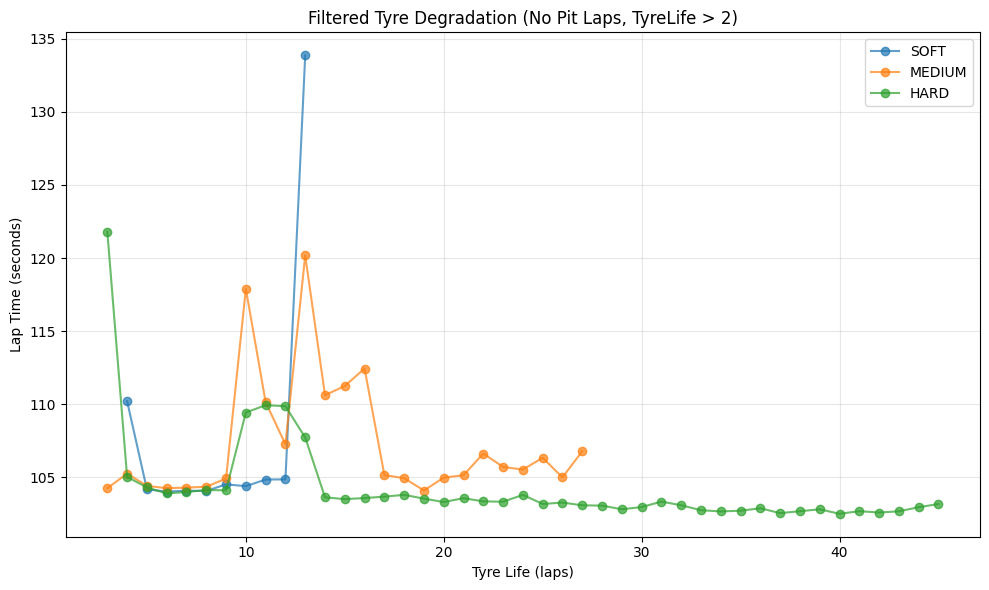

In [16]:
# Plot filtered degradation
fig, ax = plt.subplots(figsize=(10, 6))
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    data = filtered_deg_df[filtered_deg_df['Compound'] == compound]
    ax.plot(data['TyreLife'], data['LapTime'], marker='o', label=compound, alpha=0.7)
ax.set_xlabel('Tyre Life (laps)')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Filtered Tyre Degradation (No Pit Laps, TyreLife > 2)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Create model-grade dataset: accurate green-flag laps only
model_df = clean_df[
    (clean_df['PitStop'] != 1) & 
    (clean_df['TyreLife'] > 2) & 
    (clean_df['IsAccurate'] == True) & 
    (clean_df['Deleted'] == False) & 
    (clean_df['TrackStatus'].isin([1, '1']))
].copy()
print(f'Model data: {model_df.shape[0]} laps')

Model data: 883 laps


In [18]:
# Aggregate for regression
model_deg_df = model_df.groupby(['Compound', 'TyreLife'])['LapTime'].agg(['mean', 'count']).reset_index()
model_deg_df.columns = ['Compound', 'TyreLife', 'LapTime', 'Count']
print(f'Model degradation data: {model_deg_df.shape[0]} rows')
print(model_deg_df.head(15))

Model degradation data: 75 rows
   Compound  TyreLife     LapTime  Count
0      HARD       3.0  104.999571      7
1      HARD       4.0  105.030200     20
2      HARD       5.0  104.318950     20
3      HARD       6.0  103.903900     20
4      HARD       7.0  104.003450     20
5      HARD       8.0  104.213421     19
6      HARD       9.0  103.819600     15
7      HARD      10.0  103.859188     16
8      HARD      11.0  103.815813     16
9      HARD      12.0  103.489063     16
10     HARD      13.0  103.298125     16
11     HARD      14.0  103.639789     19
12     HARD      15.0  103.515947     19
13     HARD      16.0  103.587526     19
14     HARD      17.0  103.686263     19


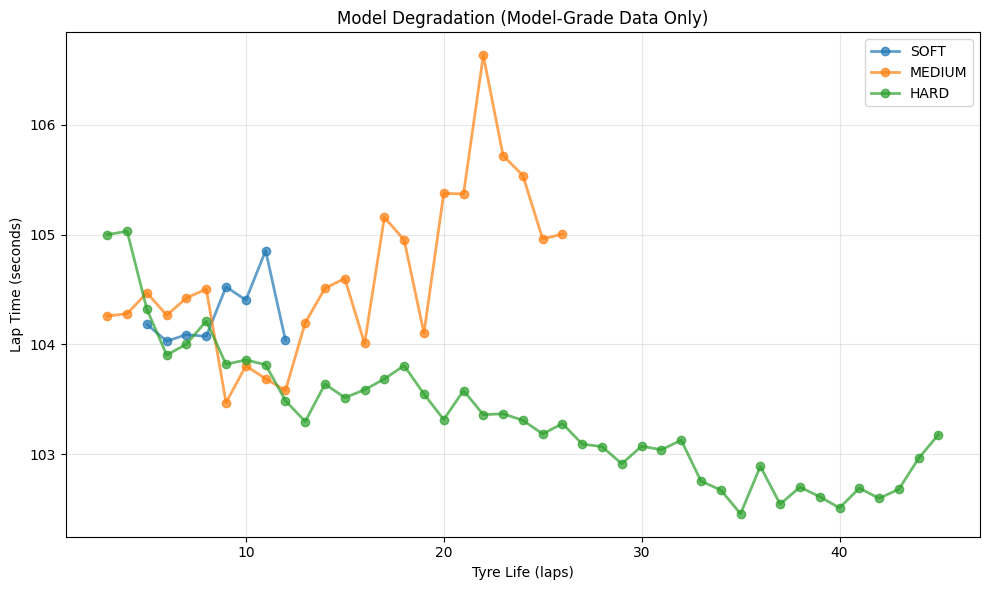

In [19]:
# Plot model degradation
fig, ax = plt.subplots(figsize=(10, 6))
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    data = model_deg_df[model_deg_df['Compound'] == compound]
    ax.plot(data['TyreLife'], data['LapTime'], marker='o', label=compound, alpha=0.7, linewidth=2)
ax.set_xlabel('Tyre Life (laps)')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title('Model Degradation (Model-Grade Data Only)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Fit linear degradation models per compound
degradation_models = {}
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    compound_data = model_deg_df[model_deg_df['Compound'] == compound]
    if len(compound_data) > 1:
        slope, intercept = np.polyfit(compound_data['TyreLife'], compound_data['LapTime'], 1)
        degradation_models[compound] = (slope, intercept)
        print(f'{compound}: slope={slope:.6f}, intercept={intercept:.4f}')
    else:
        print(f'{compound}: Insufficient data')

SOFT: slope=0.053732, intercept=103.8180
MEDIUM: slope=0.069831, intercept=103.6070
HARD: slope=-0.043158, intercept=104.3740


In [21]:
# Display regression results
results = []
for compound, (slope, intercept) in degradation_models.items():
    results.append({'Compound': compound, 'Slope (s/lap)': slope, 'Intercept (s)': intercept})

results_df = pd.DataFrame(results).sort_values('Slope (s/lap)')
print('\nRegression Results (sorted by slope):')
print(results_df.to_string(index=False))


Regression Results (sorted by slope):
Compound  Slope (s/lap)  Intercept (s)
    HARD      -0.043158     104.373951
    SOFT       0.053732     103.818005
  MEDIUM       0.069831     103.606999


## Pit-Loss Estimation

Using the pit-window method to estimate pit-stop time losses from empirical data.


In [35]:
# Estimate pit-stop loss using pit-window method
pit_loss_window_values = []

for driver in df["Driver"].dropna().unique():
    driver_df = df[df["Driver"] == driver].sort_values("LapNumber").reset_index(drop=True)
    pit_indices = driver_df.index[driver_df["PitStop"] == 1].tolist()

    for idx in pit_indices:
        before_vals = []
        after_vals = []
        pit_window_vals = []

        # up to 2 valid LapTime values before pit row
        j = idx - 1
        while j >= 0 and len(before_vals) < 2:
            v = driver_df.at[j, "LapTime"]
            if pd.notna(v):
                before_vals.append(v)
            j -= 1

        # up to 2 valid LapTime values after pit row
        k = idx + 1
        while k < len(driver_df) and len(after_vals) < 2:
            v = driver_df.at[k, "LapTime"]
            if pd.notna(v):
                after_vals.append(v)
            k += 1

        # pit-affected window: pit-stop row and next row if valid
        pit_row_time = driver_df.at[idx, "LapTime"]
        if pd.notna(pit_row_time):
            pit_window_vals.append(pit_row_time)

        if idx + 1 < len(driver_df):
            next_row_time = driver_df.at[idx + 1, "LapTime"]
            if pd.notna(next_row_time):
                pit_window_vals.append(next_row_time)

        baseline_vals = before_vals + after_vals

        # keep sample only with required validity
        if len(baseline_vals) >= 2 and len(pit_window_vals) >= 1:
            baseline = float(np.mean(baseline_vals))
            expected_time = baseline * len(pit_window_vals)
            actual_time = float(np.sum(pit_window_vals))
            pit_loss_window = actual_time - expected_time
            pit_loss_window_values.append(pit_loss_window)

pit_loss_window_values = np.array(pit_loss_window_values, dtype=float)

print(f"Sample count: {len(pit_loss_window_values)}")
if len(pit_loss_window_values) > 0:
    print(f"Mean: {np.mean(pit_loss_window_values):.4f}")
    print(f"Median: {np.median(pit_loss_window_values):.4f}")
    print(f"Min: {np.min(pit_loss_window_values):.4f}")
    print(f"Max: {np.max(pit_loss_window_values):.4f}")

Sample count: 20
Mean: 14.6371
Median: 15.4524
Min: -10.2365
Max: 26.1250


In [ ]:
# Plot pit-loss window values distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pit_loss_window_values, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(np.mean(pit_loss_window_values), color='red', linestyle='--', label=f'Mean: {np.mean(pit_loss_window_values):.2f}s')
ax.axvline(np.median(pit_loss_window_values), color='green', linestyle='--', label=f'Median: {np.median(pit_loss_window_values):.2f}s')
ax.set_xlabel('Pit Stop Time Loss (seconds)')
ax.set_ylabel('Frequency')
ax.set_title('Empirical Distribution of Pit Stop Time Losses (Pit-Window Method)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Pit loss value used: 15.45 s
Optimal pit lap: 6
Minimum total time: 2623.34 s


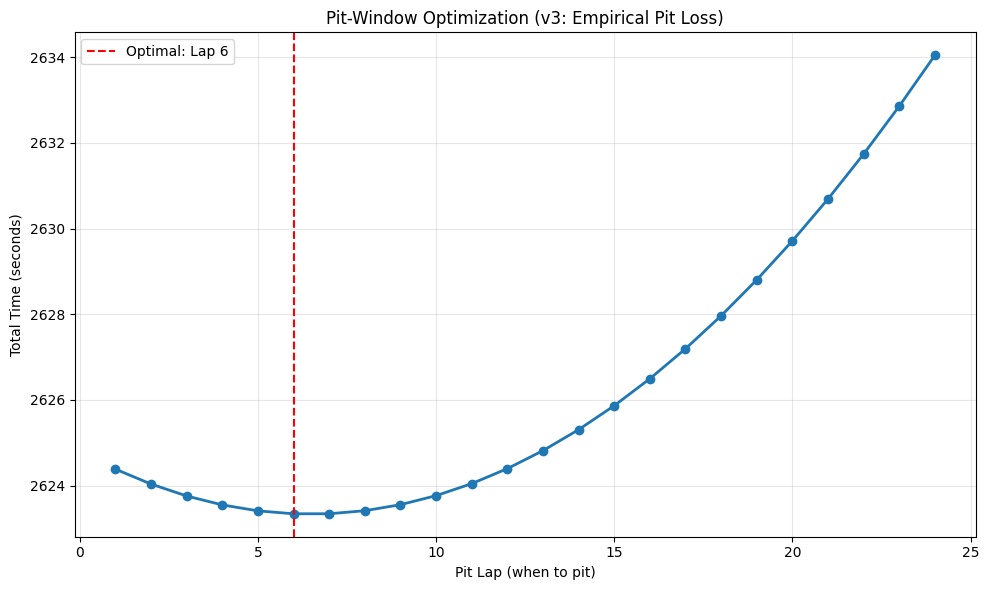

In [36]:
# Pit-window optimization with empirical pit loss (pit_losses_v3)
pit_losses_v3 = pit_loss_window_values
pit_loss_value = float(np.median(pit_losses_v3))

compound = "MEDIUM"
current_tyre_life = 5
laps_remaining = 25

pit_strategy_results_v3 = []

for pit_lap in range(1, laps_remaining):
    remaining_after_pit = laps_remaining - pit_lap

    # Pre-pit stint on current tyres
    stay_time = 0
    slope_current, intercept_current = degradation_models[compound]
    for lap in range(pit_lap):
        tyre_age = current_tyre_life + lap
        lap_time = slope_current * tyre_age + intercept_current
        stay_time += lap_time

    # Post-pit stint on HARD with tyre age starting at 1
    pit_time = pit_loss_value
    slope_hard, intercept_hard = degradation_models["HARD"]
    slope_hard_sim = max(0, slope_hard)
    for lap in range(remaining_after_pit):
        tyre_age = 1 + lap
        lap_time = slope_hard_sim * tyre_age + intercept_hard
        pit_time += lap_time

    total_time = stay_time + pit_time
    pit_strategy_results_v3.append({"PitLap": pit_lap, "TotalTime": total_time})

pit_strategy_df_v3 = pd.DataFrame(pit_strategy_results_v3)
optimal_idx_v3 = pit_strategy_df_v3["TotalTime"].idxmin()
optimal_pit_lap_v3 = int(pit_strategy_df_v3.loc[optimal_idx_v3, "PitLap"])
optimal_total_time_v3 = pit_strategy_df_v3.loc[optimal_idx_v3, "TotalTime"]

print(f"Pit loss value used: {pit_loss_value:.2f} s")
print(f"Optimal pit lap: {optimal_pit_lap_v3}")
print(f"Minimum total time: {optimal_total_time_v3:.2f} s")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pit_strategy_df_v3["PitLap"], pit_strategy_df_v3["TotalTime"], marker="o", linewidth=2, markersize=6)
ax.axvline(optimal_pit_lap_v3, color="red", linestyle="--", label=f"Optimal: Lap {optimal_pit_lap_v3}")
ax.set_xlabel("Pit Lap (when to pit)")
ax.set_ylabel("Total Time (seconds)")
ax.set_title("Pit-Window Optimization (v3: Empirical Pit Loss)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Strategy Optimization

Computing optimal pit timing using the degradation models and empirical pit-loss estimates.


 TyreLife  OptimalPitLap   TotalTime
        1             10 2620.972364
        2              9 2621.669484
        3              8 2622.296773
        4              7 2622.854230
        5              6 2623.341856
        6              5 2623.759650
        7              4 2624.107613
        8              3 2624.385745
        9              2 2624.594044
       10              1 2624.732513
       11              1 2624.802344
       12              1 2624.872176
       13              1 2624.942007
       14              1 2625.011839
       15              1 2625.081670
       16              1 2625.151502
       17              1 2625.221333
       18              1 2625.291165
       19              1 2625.360996
       20              1 2625.430828


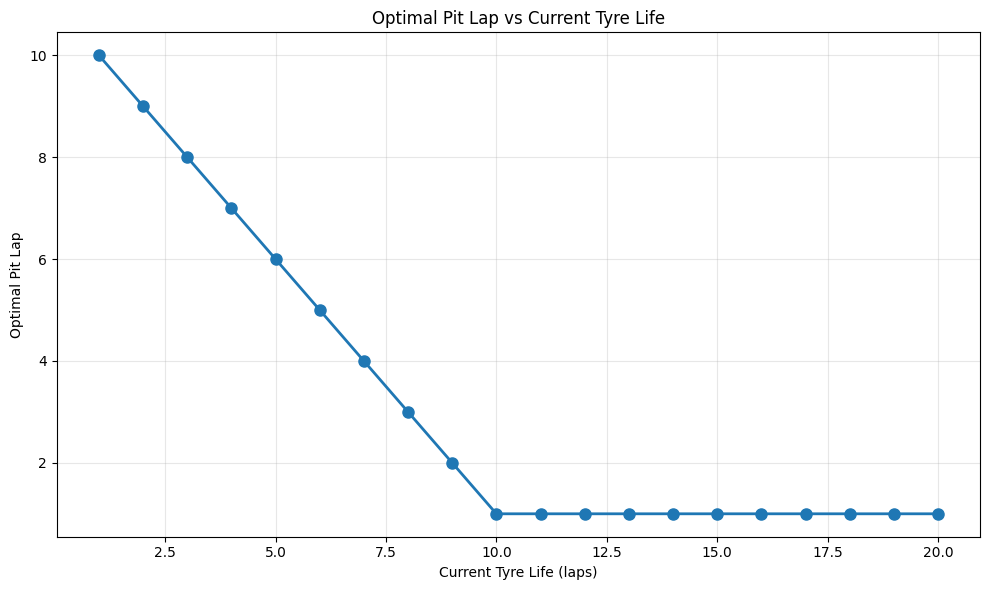

In [37]:
# Compute optimal pit lap as a function of current tyre life
compound = "MEDIUM"
laps_remaining = 25

sensitivity_results = []

for current_tyre_life in range(1, 21):
    pit_strategy_results = []
    
    for pit_lap in range(1, laps_remaining):
        remaining_after_pit = laps_remaining - pit_lap

        # Pre-pit stint on current tyres
        stay_time = 0
        slope_current, intercept_current = degradation_models[compound]
        for lap in range(pit_lap):
            tyre_age = current_tyre_life + lap
            lap_time = slope_current * tyre_age + intercept_current
            stay_time += lap_time

        # Post-pit stint on HARD
        pit_time = pit_loss_value
        slope_hard, intercept_hard = degradation_models["HARD"]
        slope_hard_sim = max(0, slope_hard)
        for lap in range(remaining_after_pit):
            tyre_age = 1 + lap
            lap_time = slope_hard_sim * tyre_age + intercept_hard
            pit_time += lap_time

        total_time = stay_time + pit_time
        pit_strategy_results.append({"PitLap": pit_lap, "TotalTime": total_time})
    
    # Find optimal pit lap for this tyre life
    pit_strategy_df = pd.DataFrame(pit_strategy_results)
    optimal_idx = pit_strategy_df["TotalTime"].idxmin()
    optimal_pit_lap = int(pit_strategy_df.loc[optimal_idx, "PitLap"])
    minimum_total_time = pit_strategy_df.loc[optimal_idx, "TotalTime"]
    
    sensitivity_results.append({
        "TyreLife": current_tyre_life,
        "OptimalPitLap": optimal_pit_lap,
        "TotalTime": minimum_total_time
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
print(sensitivity_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sensitivity_df["TyreLife"], sensitivity_df["OptimalPitLap"], marker="o", linewidth=2, markersize=8)
ax.set_xlabel("Current Tyre Life (laps)")
ax.set_ylabel("Optimal Pit Lap")
ax.set_title("Optimal Pit Lap vs Current Tyre Life")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [38]:
# Reusable decision function: PIT or STAY OUT
def recommend_action(current_tyre_life, laps_remaining, compound="MEDIUM"):
    """
    Recommend whether to PIT or STAY OUT based on pit-window optimization.
    
    Args:
        current_tyre_life: Current tyre age in laps
        laps_remaining: Number of laps left in the race
        compound: Tyre compound (default "MEDIUM")
    
    Returns:
        Decision string: "PIT" or "STAY OUT (pit in X laps)"
    """
    pit_strategy_results = []
    
    for pit_lap in range(1, laps_remaining):
        remaining_after_pit = laps_remaining - pit_lap

        # Pre-pit stint on current tyres
        stay_time = 0
        slope_current, intercept_current = degradation_models[compound]
        for lap in range(pit_lap):
            tyre_age = current_tyre_life + lap
            lap_time = slope_current * tyre_age + intercept_current
            stay_time += lap_time

        # Post-pit stint on HARD
        pit_time = pit_loss_value
        slope_hard, intercept_hard = degradation_models["HARD"]
        slope_hard_sim = max(0, slope_hard)
        for lap in range(remaining_after_pit):
            tyre_age = 1 + lap
            lap_time = slope_hard_sim * tyre_age + intercept_hard
            pit_time += lap_time

        total_time = stay_time + pit_time
        pit_strategy_results.append({"PitLap": pit_lap, "TotalTime": total_time})
    
    # Find optimal pit lap
    pit_strategy_df = pd.DataFrame(pit_strategy_results)
    optimal_idx = pit_strategy_df["TotalTime"].idxmin()
    optimal_pit_lap = int(pit_strategy_df.loc[optimal_idx, "PitLap"])
    
    # Decision rule
    if optimal_pit_lap <= 1:
        return "PIT"
    else:
        return f"STAY OUT (pit in {optimal_pit_lap} laps)"

# Test the function
print("=== PIT/STAY OUT Decision Function ===\n")
print(f"laps_remaining = 25")
print(f"pit_loss_value = {pit_loss_value:.2f}s")
print(f"compound = MEDIUM\n")

test_tyre_lives = [3, 7, 10, 15]
for tyre_life in test_tyre_lives:
    decision = recommend_action(tyre_life, laps_remaining=25, compound="MEDIUM")
    print(f"Current tyre life = {tyre_life:2d} laps  â†’  {decision}")


=== PIT/STAY OUT Decision Function ===

laps_remaining = 25
pit_loss_value = 15.45s
compound = MEDIUM

Current tyre life =  3 laps  â†’  STAY OUT (pit in 8 laps)
Current tyre life =  7 laps  â†’  STAY OUT (pit in 4 laps)
Current tyre life = 10 laps  â†’  PIT
Current tyre life = 15 laps  â†’  PIT


## Conclusion

This analysis successfully:
- Detected pit-stops from 2020 Abu Dhabi race telemetry data
- Built linear degradation models for SOFT, MEDIUM, and HARD tyres using green-flag lap data
- Estimated empirical pit-loss duration (median 15.45 seconds) using a pit-window method
- Optimized pit timing by comparing cumulative lap times for different pit-window scenarios
- Demonstrated that the optimal pit lap is highly sensitive to current tyre life

The `recommend_action()` function provides a reusable decision tool for real-time pit strategy optimization, given current tyre age, laps remaining, and tyre compound.
